# EDA TP Grupo N°13 — Yellow Taxi NYC (26Co2026)

Análisis exploratorio simple.

Integrantes:
- Fioranelli, Rocío
- Lerner, Federico
- Makk, Azul
- Moguilner Reh, Nicolás
- Varela, Gustavo



### NYC TLC Trip Record Data Dictionary

Fuente: [http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml](http://www.nyc.gov/html/tlc/html/about/trip_record_data.shtml)

| Field Name | Description |
|---|---|
| `VendorID` | A code indicating the TPEP provider that provided the record.<br>1 = Creative Mobile Technologies, LLC<br>2 = Curb Mobility, LLC<br>6 = Myle Technologies Inc<br>7 = Helix |
| `tpep_pickup_datetime` | The date and time when the meter was engaged. |
| `tpep_dropoff_datetime` | The date and time when the meter was disengaged. |
| `passenger_count` | The number of passengers in the vehicle. |
| `trip_distance` | The elapsed trip distance in miles reported by the taximeter. |
| `RatecodeID` | The final rate code in effect at the end of the trip.<br>1 = Standard rate<br>2 = JFK<br>3 = Newark<br>4 = Nassau or Westchester<br>5 = Negotiated fare<br>6 = Group ride<br>99 = Null/unknown |
| `store_and_fwd_flag` | This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka "store and forward," because the vehicle did not have a connection to the server.<br>Y = store and forward trip<br>N = not a store and forward trip |
| `PULocationID` | TLC Taxi Zone in which the taximeter was engaged. |
| `DOLocationID` | TLC Taxi Zone in which the taximeter was disengaged. |
| `payment_type` | A numeric code signifying how the passenger paid for the trip.<br>0 = Flex Fare trip<br>1 = Credit card<br>2 = Cash<br>3 = No charge<br>4 = Dispute<br>5 = Unknown<br>6 = Voided trip |
| `fare_amount` | The time-and-distance fare calculated by the meter. For additional information on the following columns, see https://www.nyc.gov/site/tlc/passengers/taxi-fare.page |
| `extra` | Miscellaneous extras and surcharges. |
| `mta_tax` | Tax that is automatically triggered based on the metered rate in use. |
| `tip_amount` | Tip amount. This field is automatically populated for credit card tips. Cash tips are not included. |
| `tolls_amount` | Total amount of all tolls paid in trip. |
| `improvement_surcharge` | Improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
| `total_amount` | Total amount charged to passengers. Does not include cash tips. |
| `congestion_surcharge` | Total amount collected in trip for NYS congestion surcharge. |
| `airport_fee` | For pick up only at LaGuardia and John F. Kennedy Airports. |
| `cbd_congestion_fee` | Per-trip charge for MTA's Congestion Relief Zone starting Jan 5, 2025. |

In [1]:
from pathlib import Path
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [2]:
DATA_PATH = Path("dataset") / "yellow_tripdata_2026-03.parquet"
df = pd.read_parquet(DATA_PATH)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-03-01 00:02:26,2026-03-01 00:13:45,1.0,2.58,1.0,N,48,151,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
1,2,2026-03-01 00:19:33,2026-03-01 00:28:21,1.0,1.50,1.0,N,238,166,1,10.0,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.0,0.00
2,2,2026-03-01 00:07:20,2026-03-01 00:15:12,2.0,0.88,1.0,N,90,249,1,8.6,1.0,0.5,2.87,0.0,1.0,17.22,2.5,0.0,0.75
3,2,2026-03-01 00:16:11,2026-03-01 00:28:20,1.0,1.76,1.0,N,249,137,1,12.1,1.0,0.5,3.57,0.0,1.0,21.42,2.5,0.0,0.75
4,2,2026-03-01 00:20:47,2026-03-01 00:30:44,2.0,1.57,1.0,N,100,142,1,11.4,1.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75


In [3]:
print("Filas, columnas:", df.shape)
df.dtypes

Filas, columnas: (3952451, 20)


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [4]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3952451 entries, 0 to 3952450
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [5]:
df.describe().round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3952451.00,3952451,3952451,3006703.00,3952451.00,3006703.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3952451.00,3006703.00,3006703.00,3952451.00
mean,1.88,2026-03-16 09:09:15.947559,2026-03-16 09:26:33.369682,1.23,5.98,5.64,161.51,160.86,0.88,21.33,1.12,0.49,2.86,0.53,0.95,30.10,2.19,0.16,0.53
min,1.00,2008-12-31 23:03:20,2009-01-01 00:07:36,0.00,0.00,1.00,1.00,1.00,0.00,-990.00,-7.50,-0.50,-75.75,-111.79,-1.00,-1022.46,-2.50,-2.00,-0.75
25%,2.00,2026-03-08 17:38:26,2026-03-08 17:55:32,1.00,1.01,1.00,114.00,107.00,1.00,10.00,0.00,0.50,0.00,0.00,1.00,17.22,2.50,0.00,0.00
50%,2.00,2026-03-16 08:13:05,2026-03-16 08:32:14,1.00,1.82,1.00,161.00,162.00,1.00,15.60,0.00,0.50,2.11,0.00,1.00,23.40,2.50,0.00,0.75
75%,2.00,2026-03-23 17:55:51.500000,2026-03-23 18:13:19,1.00,3.71,1.00,233.00,234.00,1.00,26.80,2.50,0.50,3.95,0.00,1.00,34.90,2.50,0.00,0.75
max,7.00,2026-04-01 00:06:25,2026-04-02 16:03:47,8.00,288381.68,99.00,265.00,265.00,4.00,1843.30,17.46,4.75,397.00,1400.00,1.00,1850.55,2.50,27.00,0.75
std,0.72,NaN,NaN,0.63,581.05,20.59,66.57,70.71,0.63,18.69,1.75,0.09,3.91,2.29,0.24,22.41,0.87,0.55,0.35


In [6]:
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

Airport_fee             945748
passenger_count         945748
congestion_surcharge    945748
RatecodeID              945748
store_and_fwd_flag      945748
dtype: int64

In [7]:
print('cantidad de pasajeros max transportados en un viaje:', (df['passenger_count']).max())

print('viajes con +2 pasajeros', (df['passenger_count'] > 2).sum())

print('viajes con +3 pasajeros', (df['passenger_count'] > 3).sum())

print('viajes con +4 pasajeros', (df['passenger_count'] > 4).sum())

print('viajes con +5 pasajeros', (df['passenger_count'] > 5).sum())

print('viajes con +5 pasajeros', (df['passenger_count'] > 7).sum())

df['passenger_count'].describe()

cantidad de pasajeros max transportados en un viaje: 8.0
viajes con +2 pasajeros 137659
viajes con +3 pasajeros 61761
viajes con +4 pasajeros 13612
viajes con +5 pasajeros 5130
viajes con +5 pasajeros 3


count    3.006703e+06
mean     1.230823e+00
std      6.330375e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      8.000000e+00
Name: passenger_count, dtype: float64

In [8]:
df['payment_type'].describe()

# 0: Flex Fare trip
# 1: Credit card
# 2: Cash
# 3: No charge
# 4: Dispute
# 5: Unknown
# 6: Voided trip

count    3.952451e+06
mean     8.805670e-01
std      6.317968e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23564\2092868268.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


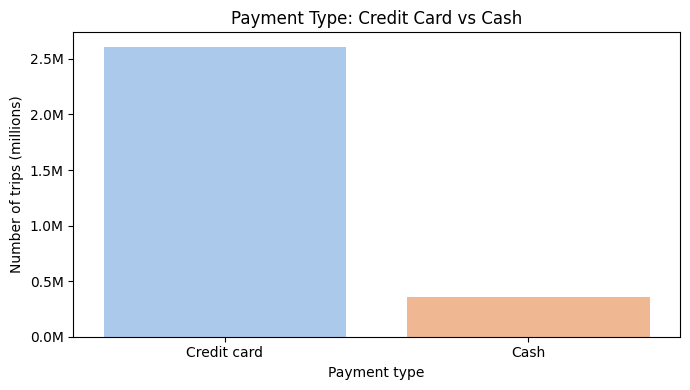

In [9]:
import matplotlib.ticker as mtick

plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df[df['payment_type'].isin([1, 2])],
    x='payment_type',
    order=[1, 2],
    palette='pastel'
)

plt.xticks([0, 1], ['Credit card', 'Cash'])
plt.title('Payment Type: Credit Card vs Cash')
plt.xlabel('Payment type')
plt.ylabel('Number of trips (millions)')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

plt.tight_layout()
plt.show()

In [10]:
df['tip_amount'].describe() # solo tarjeta cred, calcula automaticamente

print(f'hay {(df['tip_amount'] < 0).sum()} propinas negativas. se pagó de menos, ajuste contable?')
print(f'el 50% deja entre {(df['tip_amount']).quantile(0.25)} y {(df['tip_amount']).quantile(0.75)} usd de propina, el promedio es de {df["tip_amount"].mean():.2f}')
print(f'la propina máxima fue de {df["tip_amount"].max():.2f} usd')

hay 40 propinas negativas. se pagó de menos, ajuste contable?
el 50% deja entre 0.0 y 3.95 usd de propina, el promedio es de 2.86
la propina máxima fue de 397.00 usd


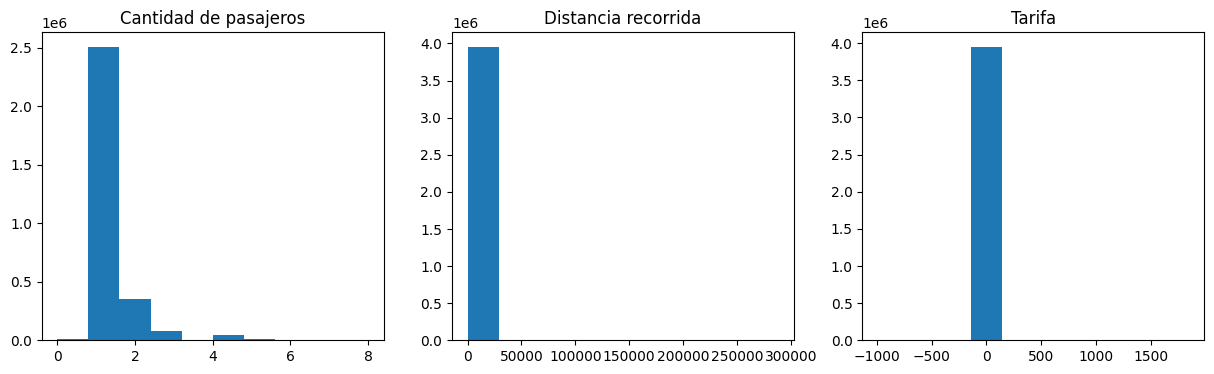

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(df['passenger_count'])
ax[0].set_title('Cantidad de pasajeros')
ax[1].hist(df['trip_distance']) 
ax[1].set_title('Distancia recorrida')
ax[2].hist(df['fare_amount'])
ax[2].set_title('Tarifa')

plt.show()
# hay outliers

In [12]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

trip_distance_Q1, trip_distance_Q2, trip_distance_Q3 = cuartiles(df['trip_distance'])

print("Q1 (25%):", trip_distance_Q1, "millas")
print("Q2 (Mediana, 50%):", trip_distance_Q2, "millas")
print("Q3 (75%):", trip_distance_Q3, "millas")

trip_distance_IQR = trip_distance_Q3 - trip_distance_Q1
print("Rango intercuartil (IQR):", trip_distance_IQR, "millas")

Q1 (25%): 1.01 millas
Q2 (Mediana, 50%): 1.82 millas
Q3 (75%): 3.71 millas
Rango intercuartil (IQR): 2.7 millas


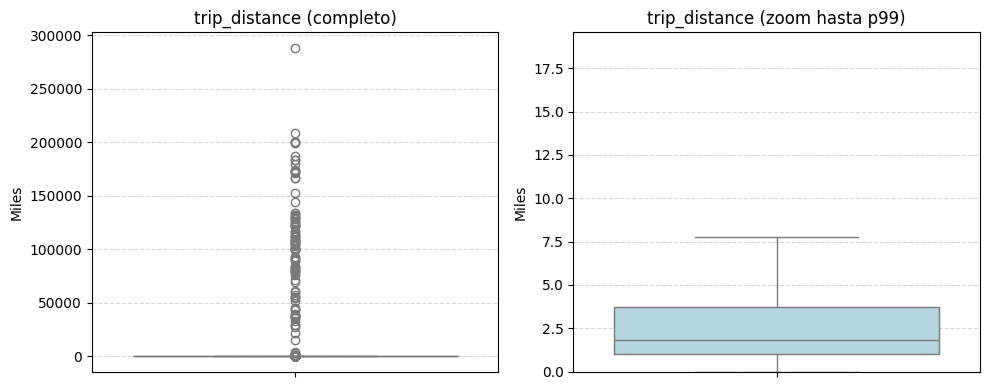

p99 de trip_distance: 19.58


In [16]:
trip_distance = df['trip_distance'].dropna()
trip_distance_pos = trip_distance[trip_distance >= 0]

p99 = trip_distance_pos.quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Boxplot completo (sin ocultar outliers)
sns.boxplot(y=trip_distance_pos, color='lightblue', ax=ax[0])
ax[0].set_title('trip_distance (completo)')
ax[0].set_ylabel('Miles')
ax[0].grid(axis='y', ls='--', alpha=0.5)

# Boxplot con zoom hasta percentil 99
sns.boxplot(y=trip_distance_pos, color='lightblue', showfliers=False, ax=ax[1])
ax[1].set_ylim(0, p99)
ax[1].set_title('trip_distance (zoom hasta p99)')
ax[1].set_ylabel('Miles')
ax[1].grid(axis='y', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f'p99 de trip_distance: {p99:.2f}')

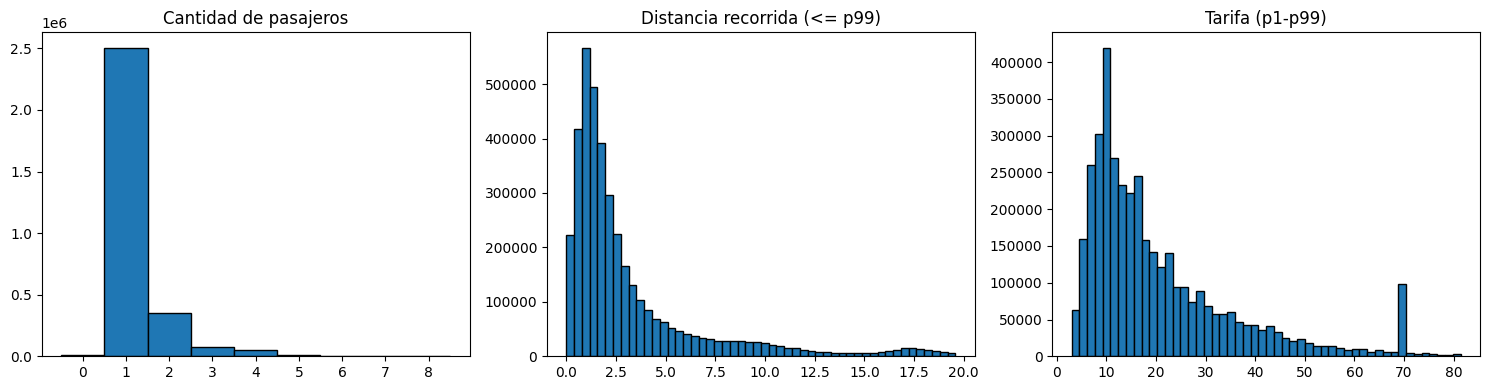

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# passenger_count como bins enteros
ax[0].hist(df['passenger_count'].dropna(), bins=np.arange(-0.5, 9.5, 1), edgecolor='black')
ax[0].set_title('Cantidad de pasajeros')
ax[0].set_xticks(range(0, 9))

# trip_distance sin extremos (p99)
d = df['trip_distance'].dropna()
d = d[(d >= 0) & (d <= d.quantile(0.99))]
ax[1].hist(d, bins=50, edgecolor='black')
ax[1].set_title('Distancia recorrida (<= p99)')

# fare_amount sin extremos (p1-p99)
f = df['fare_amount'].dropna()
f = f[(f >= f.quantile(0.01)) & (f <= f.quantile(0.99))]
ax[2].hist(f, bins=50, edgecolor='black')
ax[2].set_title('Tarifa (p1-p99)')

plt.tight_layout()
plt.show()